In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append('../')

In [2]:
from src.data_loader import get_nrel_data

# Change "csv" to "api" if you want to use the NLR API
df = get_nrel_data(source="csv")

print("Raw columns from the API:")
print(df.columns.tolist())

Loading local dataset from ../data/phoenix_2024.csv...
Raw columns from the API:
['GHI', 'DNI', 'DHI', 'Temperature', 'Wind Speed', 'Solar Zenith Angle']


In [3]:
from src.preprocessing import Z_Standardization
import numpy as np

X_scaled, y, mu, sigma = Z_Standardization(df)

# Tells you the dimension of the matrix
print(f"Shape of X_scaled (Features): {X_scaled.shape}")

print(f"Shape of y (Target): {y.shape}")

print(f"Mean of the first feature column (should be ~0): {np.mean(X_scaled[:, 0]):.5f}")

print(f"Std Dev of the first feature column (should be 1): {np.std(X_scaled[:, 0]):.5f}")

Shape of X_scaled (Features): (8760, 5)
Shape of y (Target): (8760,)
Mean of the first feature column (should be ~0): -0.00000
Std Dev of the first feature column (should be 1): 1.00000


In [4]:
from src.preprocessing import bias_column

test_size = 168

X_train_raw = X_scaled[:-test_size]
X_test_raw = X_scaled[-test_size:]

y_train = y[:-test_size]
y_test = y[-test_size:]

X_train = bias_column(X_train_raw)
X_test = bias_column(X_test_raw)

print(f"Training Features (X_train) Shape: {X_train.shape}")
print(f"Testing Features (X_test) Shape:   {X_test.shape}")
print(f"Training Target (y_train) Shape:   {y_train.shape}")

Training Features (X_train) Shape: (8592, 6)
Testing Features (X_test) Shape:   (168, 6)
Training Target (y_train) Shape:   (8592,)


Initializing the Custom Linear Regression Engine...
Training the Model on X_train...
Epoch    0 | MSE Loss: 156287.5343
Epoch  100 | MSE Loss: 13422.7801
Epoch  200 | MSE Loss: 11480.0409
Epoch  300 | MSE Loss: 11199.9693
Epoch  400 | MSE Loss: 11079.3698
Epoch  500 | MSE Loss: 11009.5675
Epoch  600 | MSE Loss: 10966.4020
Epoch  700 | MSE Loss: 10939.3225
Epoch  800 | MSE Loss: 10922.2820
Epoch  900 | MSE Loss: 10911.5519
Epoch 1000 | MSE Loss: 10904.7943
Epoch 1100 | MSE Loss: 10900.5384
Epoch 1200 | MSE Loss: 10897.8580
Epoch 1300 | MSE Loss: 10896.1700
Epoch 1400 | MSE Loss: 10895.1068
Epoch 1500 | MSE Loss: 10894.4372
Epoch 1600 | MSE Loss: 10894.0155
Epoch 1700 | MSE Loss: 10893.7499
Epoch 1800 | MSE Loss: 10893.5827
Epoch 1900 | MSE Loss: 10893.4773
Generating Predictions for X_test...

--- FINAL OOP GRADES ---
Training MSE (from model memory): 10893.4115
Testing MSE  (on unseen data):    9779.6110



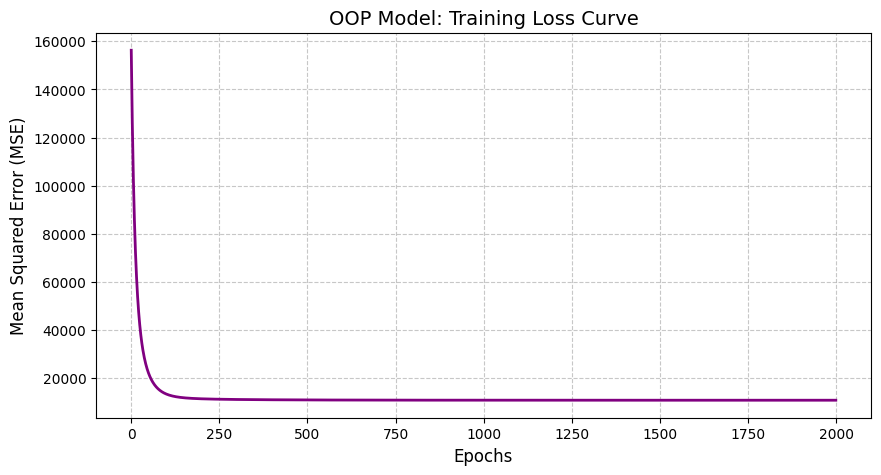

In [5]:
from src.model import CustomLinearRegression
import matplotlib.pyplot as plt
import numpy as np

print("Initializing the Custom Linear Regression Engine...")
model = CustomLinearRegression(learning_rate=0.01, epochs=2000)

print("Training the Model on X_train...")
model.fit(X_train, y_train)

print("Generating Predictions for X_test...")

predictions = model.predict(X_test)

test_mse = np.mean(np.square(predictions - y_test))

print(f"\n--- FINAL OOP GRADES ---")
print(f"Training MSE (from model memory): {model.loss_history[-1]:.4f}")
print(f"Testing MSE  (on unseen data):    {test_mse:.4f}\n")

plt.figure(figsize=(10, 5))
plt.plot(model.loss_history, color='purple', linewidth=2)
plt.title("OOP Model: Training Loss Curve", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

FINAL R-SQUARED SCORE: 80.93%



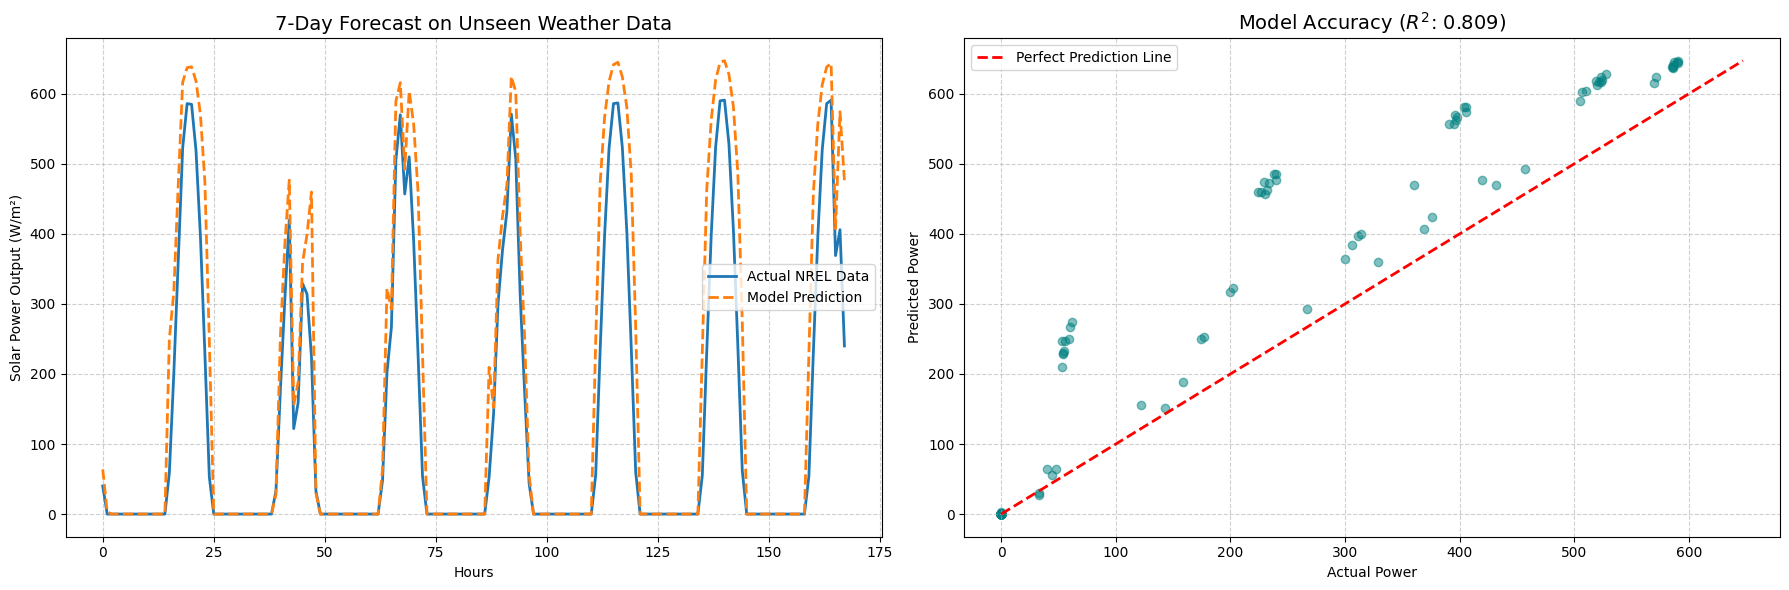

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Generate final predictions
y_pred_test = model.predict(X_test)

# ReLU
y_pred_test = np.maximum(0, y_pred_test)

# Calculating the R-Squared Score
ss_total = np.sum(np.square(y_test - np.mean(y_test)))
ss_residual = np.sum(np.square(y_test - y_pred_test))
r2_score = 1 - (ss_residual / ss_total)

print(f"FINAL R-SQUARED SCORE: {r2_score * 100:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# The 7-Day Time Series Overlay 
window = 168 # 7 days
axes[0].plot(y_test[:window], label='Actual NREL Data', color='#1f77b4', linewidth=2)
axes[0].plot(y_pred_test[:window], label='Model Prediction', color='#ff7f0e', linestyle='--', linewidth=2)
axes[0].set_title("7-Day Forecast on Unseen Weather Data", fontsize=14)
axes[0].set_ylabel("Solar Power Output (W/m²)")
axes[0].set_xlabel("Hours")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# The Scatter Plot (Actual vs Predicted) 
axes[1].scatter(y_test, y_pred_test, alpha=0.5, color='teal')

max_val = max(np.max(y_test), np.max(y_pred_test))
axes[1].plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

axes[1].set_title(f"Model Accuracy ($R^2$: {r2_score:.3f})", fontsize=14)
axes[1].set_xlabel("Actual Power")
axes[1].set_ylabel("Predicted Power")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

  SOLAR YIELD PREDICTION — LINEAR vs NON-LINEAR COMPARISON
Loading local dataset from c:\Users\PC\Base\1_Projects\Coding\AI\Solar Yield\data\phoenix_2024.csv...

Dataset shape: (8760, 6)
Features: ['GHI', 'DNI', 'DHI', 'Temperature', 'Wind Speed', 'Solar Zenith Angle']

  PIPELINE 1: LINEAR REGRESSION (Baseline)
Training samples: 7008
Test samples:     1752
Features (with bias): 6
Epoch    0 | MSE Loss: 172588.4925
Epoch  100 | MSE Loss: 13932.6028
Epoch  200 | MSE Loss: 11487.9539
Epoch  300 | MSE Loss: 11130.5285
Epoch  400 | MSE Loss: 11007.6570
Epoch  500 | MSE Loss: 10940.3175
Epoch  600 | MSE Loss: 10897.6496
Epoch  700 | MSE Loss: 10869.7202
Epoch  800 | MSE Loss: 10851.3164
Epoch  900 | MSE Loss: 10839.1732

>>> LINEAR MODEL R² = 0.7628 (76.28%)

  PIPELINE 2: NON-LINEAR REGRESSION (cos(SZA) + Poly Degree 2)
Training samples: 7008
Test samples:     1752
Features (with bias): 36
Epoch    0 | MSE Loss: 174989.8772
Epoch  100 | MSE Loss: 17023.0727
Epoch  200 | MSE Loss: 7503.3404

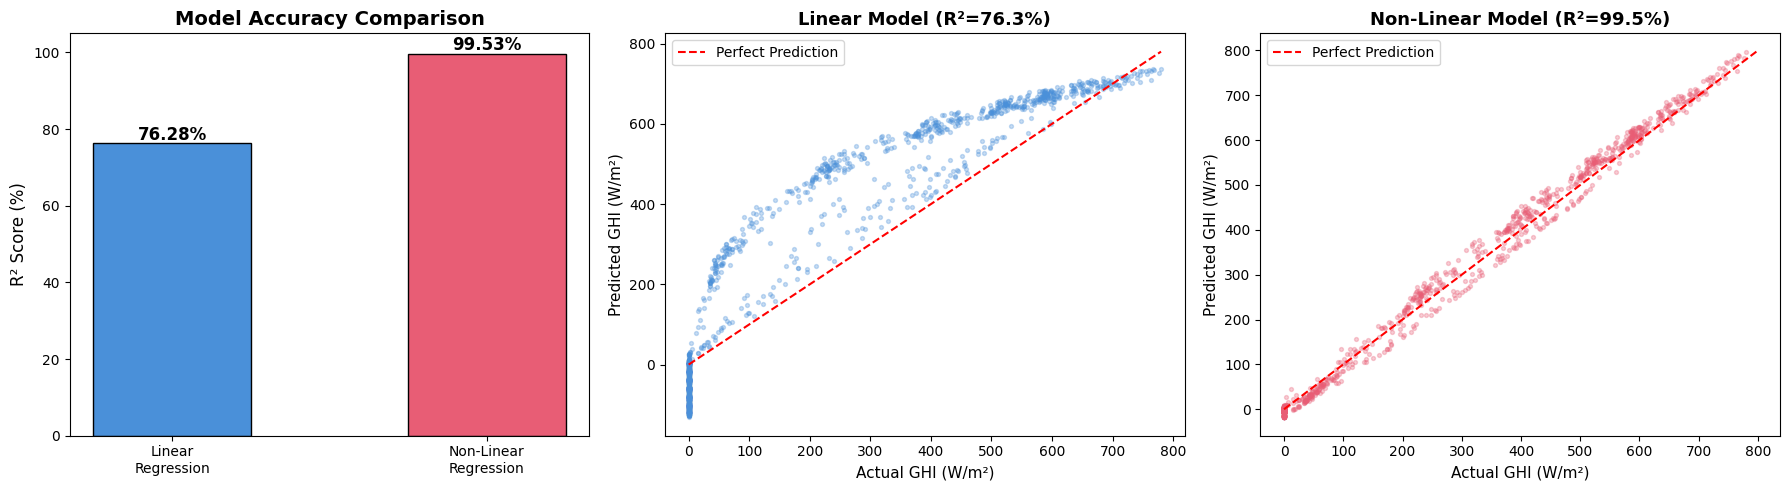

Done!


In [7]:
"""
02_nonlinear_regression.py
==========================
Compares the old Linear Regression vs the new Non-Linear Regression
(with cosine SZA transform + polynomial features).
"""
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
# NOTE: matplotlib.use('Agg') has been REMOVED so plt.show() works!

# ============================================================
#  BULLETPROOF PATHING (Works in Notebooks & Terminal)
# ============================================================
current_dir = Path.cwd()
if current_dir.name == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

# Add project root to sys.path so Python can find the 'src' folder
sys.path.insert(0, str(project_root))

from src.data_loader import get_nrel_data
from src.preprocessing import Z_Standardization, bias_column, time_series_split, preprocess_nonlinear
from src.model import CustomLinearRegression


# ============================================================
#  HELPER: Compute R² Score
# ============================================================
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


# ============================================================
#  LOAD DATA
# ============================================================
print("=" * 60)
print("  SOLAR YIELD PREDICTION — LINEAR vs NON-LINEAR COMPARISON")
print("=" * 60)

# Safely build the path to the CSV file
data_path = project_root / 'data' / 'phoenix_2024.csv'

df = get_nrel_data(source="csv", file_path=str(data_path))
print(f"\nDataset shape: {df.shape}")
print(f"Features: {list(df.columns)}")


# ============================================================
#  PIPELINE 1: OLD LINEAR MODEL (Baseline)
# ============================================================
print("\n" + "=" * 60)
print("  PIPELINE 1: LINEAR REGRESSION (Baseline)")
print("=" * 60)

X_linear, y_linear, mu_lin, sigma_lin = Z_Standardization(df)
X_linear = bias_column(X_linear)

X_train_lin, X_test_lin, y_train_lin, y_test_lin = time_series_split(X_linear, y_linear)

print(f"Training samples: {X_train_lin.shape[0]}")
print(f"Test samples:     {X_test_lin.shape[0]}")
print(f"Features (with bias): {X_train_lin.shape[1]}")

model_linear = CustomLinearRegression(learning_rate=0.01, epochs=1000)
model_linear.fit(X_train_lin, y_train_lin)

y_pred_lin = model_linear.predict(X_test_lin)
r2_linear = r2_score(y_test_lin, y_pred_lin)
print(f"\n>>> LINEAR MODEL R² = {r2_linear:.4f} ({r2_linear*100:.2f}%)")


# ============================================================
#  PIPELINE 2: NON-LINEAR MODEL (Cosine SZA + Polynomial)
# ============================================================
print("\n" + "=" * 60)
print("  PIPELINE 2: NON-LINEAR REGRESSION (cos(SZA) + Poly Degree 2)")
print("=" * 60)

X_nonlin, y_nonlin, mu_nl, sigma_nl = preprocess_nonlinear(df, poly_degree=2)
X_nonlin = bias_column(X_nonlin)

X_train_nl, X_test_nl, y_train_nl, y_test_nl = time_series_split(X_nonlin, y_nonlin)

print(f"Training samples: {X_train_nl.shape[0]}")
print(f"Test samples:     {X_test_nl.shape[0]}")
print(f"Features (with bias): {X_train_nl.shape[1]}")

# Lower learning rate for stability with many polynomial features
model_nonlinear = CustomLinearRegression(learning_rate=0.001, epochs=2000)
model_nonlinear.fit(X_train_nl, y_train_nl)

y_pred_nl = model_nonlinear.predict(X_test_nl)
r2_nonlinear = r2_score(y_test_nl, y_pred_nl)
print(f"\n>>> NON-LINEAR MODEL R² = {r2_nonlinear:.4f} ({r2_nonlinear*100:.2f}%)")


# ============================================================
#  RESULTS COMPARISON
# ============================================================
print("\n" + "=" * 60)
print("  FINAL RESULTS COMPARISON")
print("=" * 60)
print(f"  Linear Regression R²:      {r2_linear:.4f}  ({r2_linear*100:.2f}%)")
print(f"  Non-Linear Regression R²:  {r2_nonlinear:.4f}  ({r2_nonlinear*100:.2f}%)")
improvement = (r2_nonlinear - r2_linear) * 100
print(f"  Improvement:               +{improvement:.2f} percentage points")
print("=" * 60)


# ============================================================
#  GENERATE COMPARISON CHART
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: R² Bar Comparison ---
bars = axes[0].bar(['Linear\nRegression', 'Non-Linear\nRegression'],
                   [r2_linear * 100, r2_nonlinear * 100],
                   color=['#4A90D9', '#E85D75'], edgecolor='black', width=0.5)
axes[0].set_ylabel('R² Score (%)', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 105)
for bar, val in zip(bars, [r2_linear * 100, r2_nonlinear * 100]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

# --- Plot 2: Linear — Predicted vs Actual ---
axes[1].scatter(y_test_lin, y_pred_lin, alpha=0.3, s=8, color='#4A90D9')
max_val = max(y_test_lin.max(), y_pred_lin.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[1].set_xlabel('Actual GHI (W/m²)', fontsize=11)
axes[1].set_ylabel('Predicted GHI (W/m²)', fontsize=11)
axes[1].set_title(f'Linear Model (R²={r2_linear*100:.1f}%)', fontsize=13, fontweight='bold')
axes[1].legend()

# --- Plot 3: Non-Linear — Predicted vs Actual ---
axes[2].scatter(y_test_nl, y_pred_nl, alpha=0.3, s=8, color='#E85D75')
max_val = max(y_test_nl.max(), y_pred_nl.max())
axes[2].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[2].set_xlabel('Actual GHI (W/m²)', fontsize=11)
axes[2].set_ylabel('Predicted GHI (W/m²)', fontsize=11)
axes[2].set_title(f'Non-Linear Model (R²={r2_nonlinear*100:.1f}%)', fontsize=13, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()
print("Done!")